In [ ]:
# Passo 1
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregando o conjunto de dados da Model Fitness
df_gym = pd.read_csv('/datasets/gym_churn_us.csv')

# Exibindo o tamanho da base de dados (linhas, colunas)
print(df_gym.shape)

# Visualizando as 5 primeiras linhas para entender a estrutura
print(df_gym.head())

(4000, 14)
   gender  Near_Location  Partner  Promo_friends  Phone  Contract_period  \
0       1              1        1              1      0                6   
1       0              1        0              0      1               12   
2       0              1        1              0      1                1   
3       0              1        1              1      1               12   
4       1              1        1              1      1                1   

   Group_visits  Age  Avg_additional_charges_total  Month_to_end_contract  \
0             1   29                     14.227470                    5.0   
1             1   31                    113.202938                   12.0   
2             0   28                    129.448479                    1.0   
3             1   33                     62.669863                   12.0   
4             0   26                    198.362265                    1.0   

   Lifetime  Avg_class_frequency_total  Avg_class_frequency_current_m

In [ ]:
# Passo 2
print(df_gym.info())
print()
print(df_gym.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

In [ ]:
# Passo 2
# Agrupando os dados pela coluna Churn e calculando a média das características
print(df_gym.groupby('Churn').mean().T)

Churn                                       0           1
gender                               0.510037    0.510839
Near_Location                        0.873086    0.768143
Partner                              0.534195    0.355325
Promo_friends                        0.353522    0.183789
Phone                                0.903709    0.902922
Contract_period                      5.747193    1.728558
Group_visits                         0.464103    0.268615
Age                                 29.976523   26.989632
Avg_additional_charges_total       158.445715  115.082899
Month_to_end_contract                5.283089    1.662582
Lifetime                             4.711807    0.990575
Avg_class_frequency_total            2.024876    1.474995
Avg_class_frequency_current_month    2.027882    1.044546


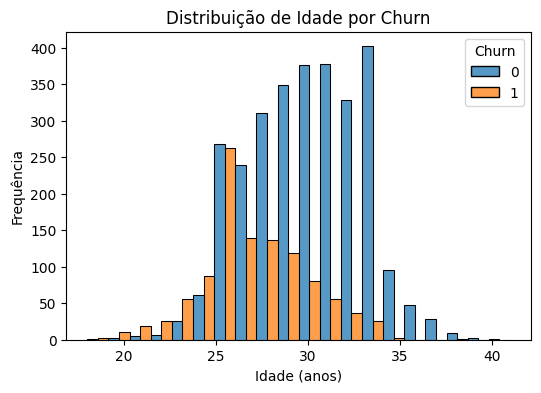

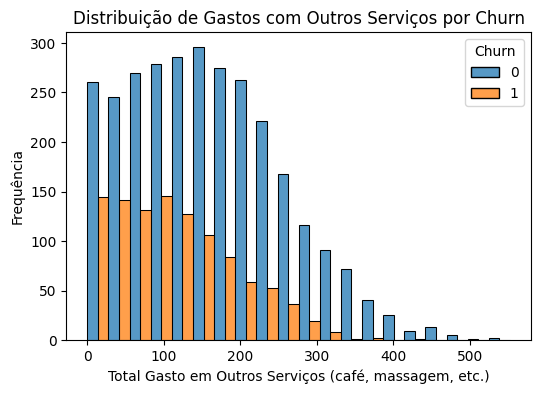

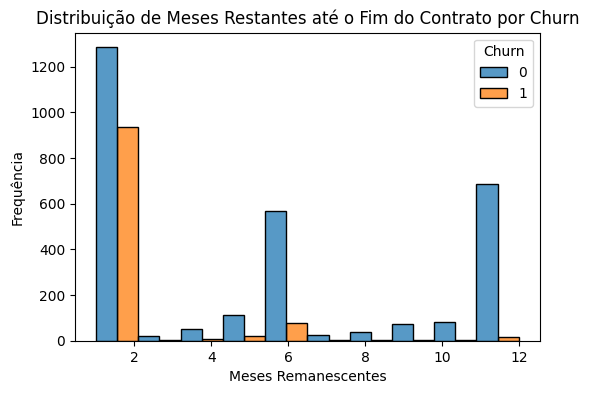

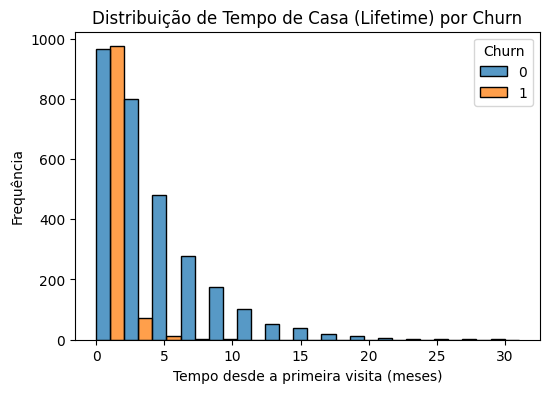

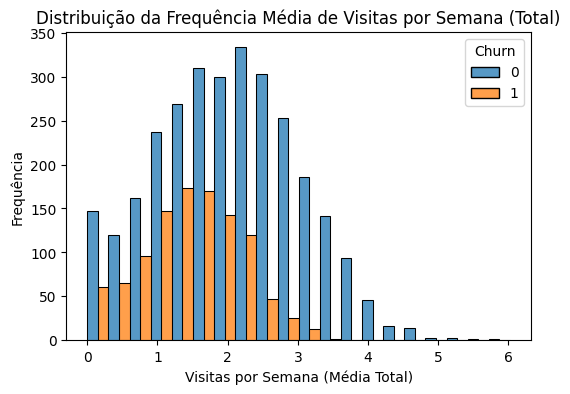

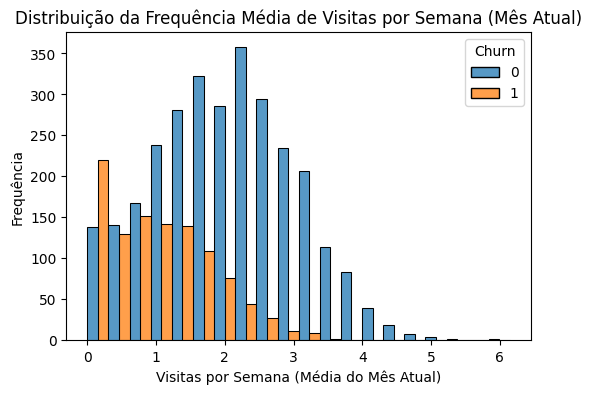

In [ ]:
# Passo 2

# -----------------------------------------------------------
# HISTOGRAMAS DE DISTRIBUIÇÃO (Para Características Numéricas)
# -----------------------------------------------------------

# 1. Distribuição de Idade
plt.figure(figsize=(6, 4))
sns.histplot(data=df_gym, x='Age', hue='Churn', kde=False, multiple='dodge', bins=20)
plt.title('Distribuição de Idade por Churn')
plt.xlabel('Idade (anos)')
plt.ylabel('Frequência')
plt.show()

# 2. Distribuição de Gastos Adicionais
plt.figure(figsize=(6, 4))
sns.histplot(data=df_gym, x='Avg_additional_charges_total', hue='Churn', kde=False, multiple='dodge', bins=20)
plt.title('Distribuição de Gastos com Outros Serviços por Churn')
plt.xlabel('Total Gasto em Outros Serviços (café, massagem, etc.)')
plt.ylabel('Frequência')
plt.show()

# 3. Distribuição de Meses Restantes no Contrato
plt.figure(figsize=(6, 4))
sns.histplot(data=df_gym, x='Month_to_end_contract', hue='Churn', kde=False, multiple='dodge', bins=10)
plt.title('Distribuição de Meses Restantes até o Fim do Contrato por Churn')
plt.xlabel('Meses Remanescentes')
plt.ylabel('Frequência')
plt.show()

# 4. Distribuição de Tempo de Casa (Lifetime)
plt.figure(figsize=(6, 4))
sns.histplot(data=df_gym, x='Lifetime', hue='Churn', kde=False, multiple='dodge', bins=15)
plt.title('Distribuição de Tempo de Casa (Lifetime) por Churn')
plt.xlabel('Tempo desde a primeira visita (meses)')
plt.ylabel('Frequência')
plt.show()

# 5. Distribuição da Frequência de Aulas Total (Histórico)
plt.figure(figsize=(6, 4))
sns.histplot(data=df_gym, x='Avg_class_frequency_total', hue='Churn', kde=False, multiple='dodge', bins=20)
plt.title('Distribuição da Frequência Média de Visitas por Semana (Total)')
plt.xlabel('Visitas por Semana (Média Total)')
plt.ylabel('Frequência')
plt.show()

# 6. Distribuição da Frequência de Aulas no Mês Atual
plt.figure(figsize=(6, 4))
sns.histplot(data=df_gym, x='Avg_class_frequency_current_month', hue='Churn', kde=False, multiple='dodge', bins=20)
plt.title('Distribuição da Frequência Média de Visitas por Semana (Mês Atual)')
plt.xlabel('Visitas por Semana (Média do Mês Atual)')
plt.ylabel('Frequência')
plt.show()

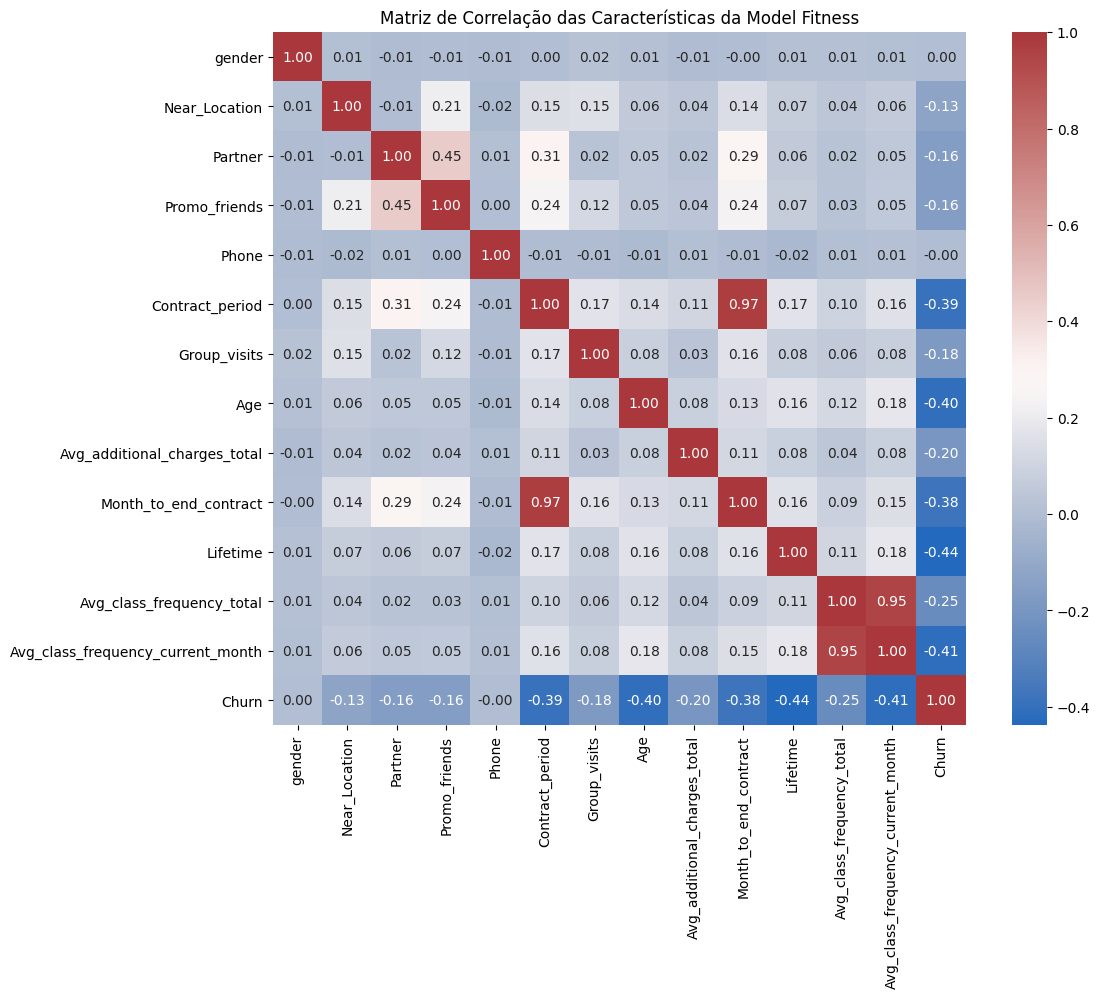

In [ ]:
# Passo 2
# Calculando a matriz de correlação para todas as colunas numéricas
corr_matrix = df_gym.corr()

# Configurando o tamanho do gráfico para que os números fiquem legíveis
plt.figure(figsize=(12, 9))

# Criando o mapa de calor (Heatmap) com anotações dos valores internos
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='vlag', square=True)

# Ajustando o título do gráfico
plt.title('Matriz de Correlação das Características da Model Fitness')
plt.show()

O diagnóstico inicial revela que o perfil propenso à desistência é marcado por contratos de curto prazo, baixo tempo de casa, frequência de treinos em queda livre no mês atual e falta de vínculos sociais na academia, como a participação em aulas de grupo ou a inscrição por indicação de amigos. Em contrapartida, os alunos fidelizados sustentam uma rotina consistente de visitas e contratos mais longos.

In [ ]:
# Passo 3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 1. Separando as características (X) e a variável objetivo (y)
X = df_gym.drop(columns=['Churn'])
y = df_gym['Churn']

# 2. Dividindo os dados em conjuntos de treinamento e validação (80% treino, 20% validação)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Padronizando as características com StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# 4. Inicializando e treinando os modelos com random_state definido
lr_model = LogisticRegression(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)

# 5. Fazendo as previsões nos dados de validação
lr_predictions = lr_model.predict(X_val_scaled)
rf_predictions = rf_model.predict(X_val_scaled)

# 6. Calculando as métricas para a Regressão Logística
lr_acuracia = accuracy_score(y_val, lr_predictions)
lr_precisao = precision_score(y_val, lr_predictions)
lr_sensibilidade = recall_score(y_val, lr_predictions)

# 7. Calculando as métricas para a Floresta Aleatória
rf_acuracia = accuracy_score(y_val, rf_predictions)
rf_precisao = precision_score(y_val, rf_predictions)
rf_sensibilidade = recall_score(y_val, rf_predictions)

# 8. Exibindo os resultados de forma direta
print("--- Métricas do Modelo: Regressão Logística ---")
print(f"Acurácia: {lr_acuracia:.4f}")
print(f"Precisão: {lr_precisao:.4f}")
print(f"Sensibilidade (Recall): {lr_sensibilidade:.4f}")
print("\n" + "="*40 + "\n")

print("--- Métricas do Modelo: Floresta Aleatória ---")
print(f"Acurácia: {rf_acuracia:.4f}")
print(f"Precisão: {rf_precisao:.4f}")
print(f"Sensibilidade (Recall): {rf_sensibilidade:.4f}")

--- Métricas do Modelo: Regressão Logística ---
Acurácia: 0.9163
Precisão: 0.8729
Sensibilidade (Recall): 0.7822


--- Métricas do Modelo: Floresta Aleatória ---
Acurácia: 0.9100
Precisão: 0.8495
Sensibilidade (Recall): 0.7822


A comparação detalhada entre os modelos revela que a Regressão Logística rendeu os melhores resultados práticos para a Model Fitness. Embora ambos os algoritmos tenham empatado na Sensibilidade, conseguindo capturar exatamente os mesmos 78.22% de clientes que realmente pretendem sair, o modelo logístico se destacou ao cravar uma Acurácia superior de 0.9163 e uma Precisão significativamente maior de 0.8729, contra 0.8495 da Floresta Aleatória. No dia a dia do negócio, essa Precisão mais alta parece ser um fator crítico, pois significa que a Regressão Logística gera muito menos alarmes falsos. Ao reduzir os falsos positivos, a academia evita classificar alunos estáveis como clientes em risco, impedindo que a empresa desperdice tempo da equipe, gaste recursos com campanhas de marketing desnecessárias ou ofereça descontos e bônus agressivos para reter pessoas que pagariam a mensalidade cheia de qualquer forma. Portanto, a escolha da Regressão Logística garante uma estratégia de retenção bem alinhada, maximizando o salvamento de clientes sem gerar prejuízos ou canibalização da receita.

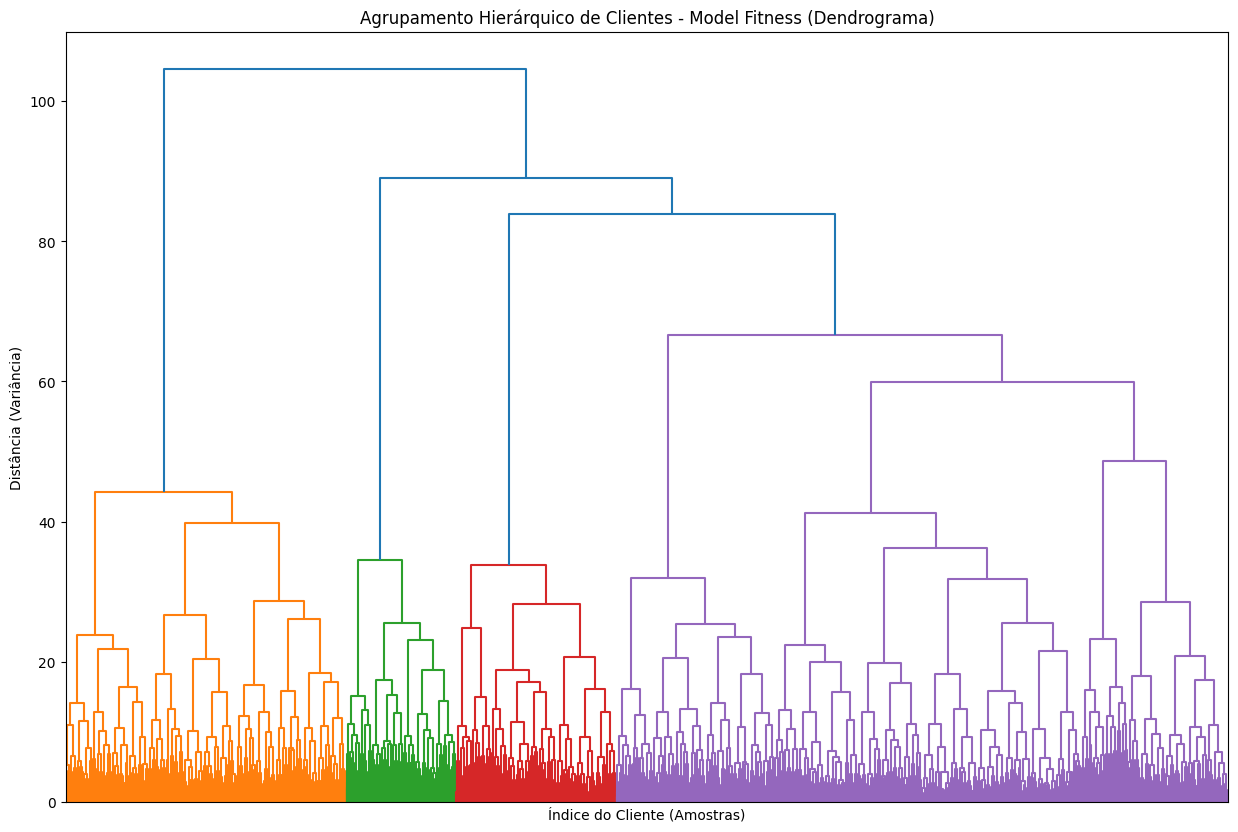

In [ ]:
# Passo 4

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# 1. Isolando a matriz de características (removendo a variável alvo Churn)
X = df_gym.drop(columns=['Churn'])

# 2. Padronizando os dados (essencial para o cálculo correto de distâncias geométricas)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Construindo a matriz de distâncias usando o método de ligação de Ward
linked = linkage(X_scaled, method='ward')

# 4. Construindo e configurando a exibição do Dendrograma
plt.figure(figsize=(15, 10))
dendrogram(linked, orientation='top', no_labels=True)

plt.title('Agrupamento Hierárquico de Clientes - Model Fitness (Dendrograma)')
plt.xlabel('Índice do Cliente (Amostras)')
plt.ylabel('Distância (Variância)')
plt.show()

In [ ]:
# Passo 4
from sklearn.cluster import KMeans
# 1. Isolando as características e padronizando os dados
X = df_gym.drop(columns=['Churn'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Inicializando o K-Means com 5 clusters e o random_state definido para reprodutibilidade
km = KMeans(n_clusters=5, random_state=42)

# 3. Treinando o modelo e prevendo os agrupamentos (clusters) para cada cliente
cluster_labels = km.fit_predict(X_scaled)

# 4. Salvando os agrupamentos de volta no nosso DataFrame original
df_gym['cluster_gym'] = cluster_labels

# 5. Exibindo a contagem de clientes em cada um dos 5 clusters
print("--- Distribuição de Clientes por Cluster ---")
print(df_gym['cluster_gym'].value_counts().sort_index())

--- Distribuição de Clientes por Cluster ---
0     633
1     889
2     865
3    1227
4     386
Name: cluster_gym, dtype: int64


In [ ]:
# Calculando a média de todas as características para cada um dos 5 clusters
tabela_medias = df_gym.groupby('cluster_gym').mean().T

# Exibindo a tabela formatada com duas casas decimais
print("--- Valores Médios das Características por Cluster ---")
print(tabela_medias.round(2))

--- Valores Médios das Características por Cluster ---
cluster_gym                             0       1       2       3       4
gender                               0.50    0.55    0.50    0.49    0.52
Near_Location                        0.95    0.85    0.94    0.72    0.86
Partner                              0.83    0.26    0.74    0.30    0.47
Promo_friends                        1.00    0.05    0.48    0.02    0.31
Phone                                1.00    1.00    1.00    1.00    0.00
Contract_period                      3.10    2.61   11.85    1.91    4.78
Group_visits                         0.45    0.44    0.55    0.28    0.43
Age                                 29.10   30.01   29.91   28.08   29.30
Avg_additional_charges_total       141.77  159.77  163.51  129.50  144.21
Month_to_end_contract                2.89    2.42   10.81    1.82    4.47
Lifetime                             3.77    4.78    4.68    2.20    3.94
Avg_class_frequency_total            1.77    2.75    2.01

- "Phone" possui quatro colunas com 1.00 e uma com 0.00, isso pode indicar que o K-Means isolou um grupo inteiro de clientes somente pelo fato de eles não terem fornecido o número de telefone no cadastro;
- A taxa de Churn por grupo está com uma variação muito alta; e
- Em relaçao a "Contract_period", um dos grupos apresentou uma média de meses de contrato muito alta (provavelmente os planos anuais), enquanto o grupo com maior índice de Churn vai ter uma média de contrato mais baixa entre os grupos.


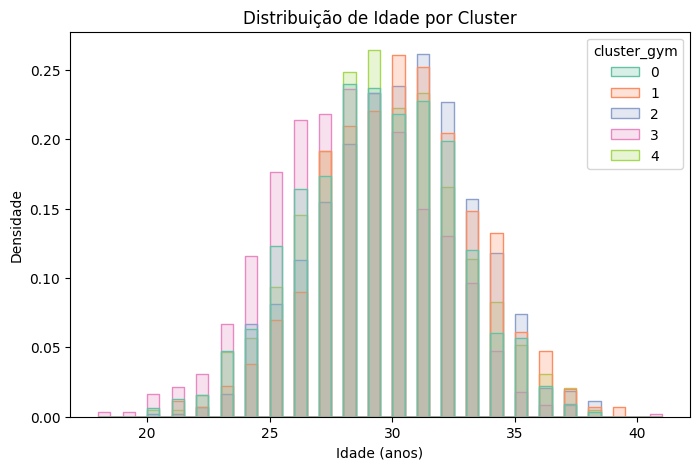

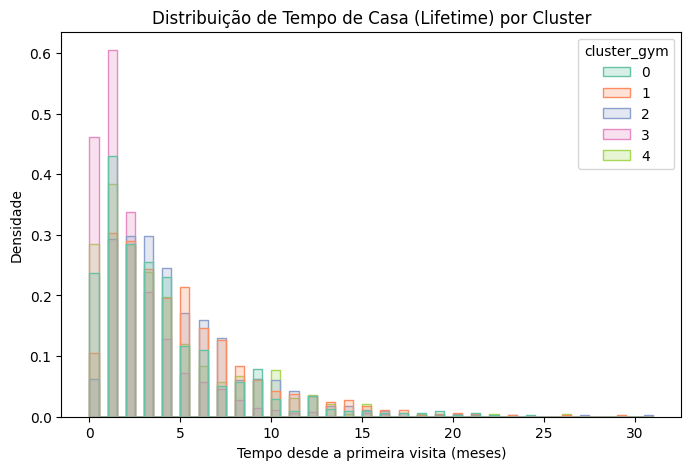

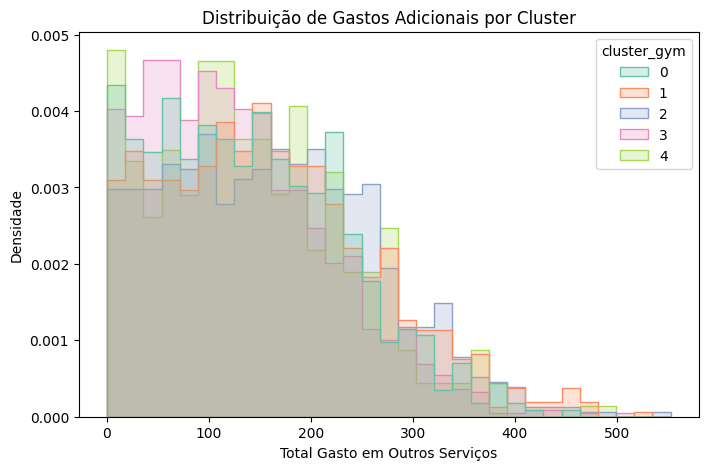

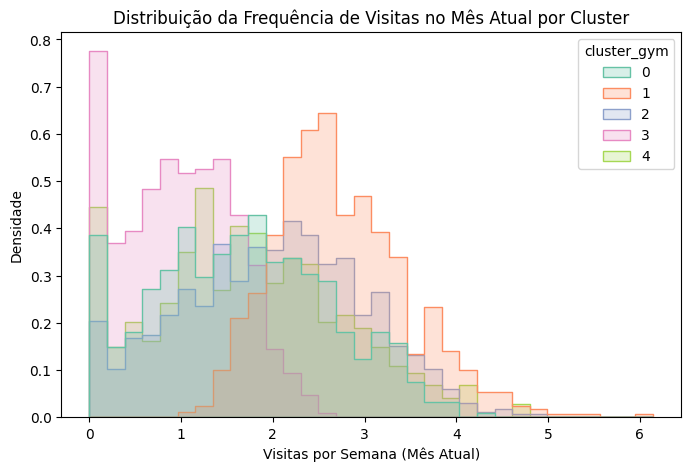

In [ ]:
# Passo 4
# -----------------------------------------------------------
# DISTRIBUIÇÕES DE CARACTERÍSTICAS POR CLUSTER
# -----------------------------------------------------------

# 1. Distribuição de Idade por Cluster
plt.figure(figsize=(8, 5))
sns.histplot(data=df_gym, x='Age', hue='cluster_gym', element='step', stat='density', common_norm=False, palette='Set2')
plt.title('Distribuição de Idade por Cluster')
plt.xlabel('Idade (anos)')
plt.ylabel('Densidade')
plt.show()

# 2. Distribuição de Tempo de Casa (Lifetime) por Cluster
plt.figure(figsize=(8, 5))
sns.histplot(data=df_gym, x='Lifetime', hue='cluster_gym', element='step', stat='density', common_norm=False, palette='Set2')
plt.title('Distribuição de Tempo de Casa (Lifetime) por Cluster')
plt.xlabel('Tempo desde a primeira visita (meses)')
plt.ylabel('Densidade')
plt.show()

# 3. Distribuição de Gastos Adicionais por Cluster
plt.figure(figsize=(8, 5))
sns.histplot(data=df_gym, x='Avg_additional_charges_total', hue='cluster_gym', element='step', stat='density', common_norm=False, palette='Set2')
plt.title('Distribuição de Gastos Adicionais por Cluster')
plt.xlabel('Total Gasto em Outros Serviços')
plt.ylabel('Densidade')
plt.show()

# 4. Distribuição da Frequência de Aulas no Mês Atual por Cluster
plt.figure(figsize=(8, 5))
sns.histplot(data=df_gym, x='Avg_class_frequency_current_month', hue='cluster_gym', element='step', stat='density', common_norm=False, palette='Set2')
plt.title('Distribuição da Frequência de Visitas no Mês Atual por Cluster')
plt.xlabel('Visitas por Semana (Mês Atual)')
plt.ylabel('Densidade')
plt.show()

Ao analisar as distribuições das características entre os agrupamentos, pode-se obeservar que o algoritmo dividiu os clientes com base em comportamentos de engajamento e barreiras claras de permanência na academia. O ponto que mais chama a atenção é o deslocamento drástico das curvas do grupo com maior taxa de evasão, que se concentra de forma massiva perto do zero no gráfico de frequência de treinos do mês atual, indicando que esse público já abandonou a rotina de atividades antes mesmo de oficializar a saída. Além disso, a distribuição do tempo de casa revela uma barreira crítica nos dois primeiros meses, onde o cluster de maior risco sofre um afunilamento agudo, enquanto os grupos estáveis se espalham de forma homogênea ao longo do tempo. Além disso, também é possível notar que esse grupo propenso ao cancelamento é composto por uma população nitidamente mais jovem, com o pico de idade deslocado para a casa dos 25 a 27 anos, e que apresenta um volume de gastos adicionais significativamente inferior aos demais clusters.
Por fim, Ao analisar a tabela de médias do Cluster 3, fica claro que o seu perfil de evasão se desenha antes mesmo de olharmos para a taxa de rotatividade. Esse grupo apresenta o menor tempo de casa (Lifetime) e o menor prazo contratual restante (Month_to_end_contract), confirmando que é composto por clientes recém-matriculados em planos mensais de curto prazo. Sem amarras contratuais ou hábitos consolidados, esse cenário se reflete diretamente na frequência de treinos do mês atual (Avg_class_frequency_current_month), que desaba para perto de zero. Isso prova que o Cluster 3 não é apenas um grupo propenso a sair no mês que vem, mas sim um público que já abandonou a rotina de treinos no presente devido à fragilidade do seu formato de entrada.

In [ ]:
# Passo 4
# Calculando a taxa de rotatividade (Churn) média para cada agrupamento
taxa_rotatividade = df_gym.groupby('cluster_gym')['Churn'].mean()

# Exibindo os resultados em formato de porcentagem para facilitar a leitura
print("--- Taxa de Rotatividade (Churn) por Agrupamento ---")
print((taxa_rotatividade * 100).round(2).astype(str) + '%')

--- Taxa de Rotatividade (Churn) por Agrupamento ---
cluster_gym
0    24.64%
1      9.0%
2      2.2%
3    57.29%
4    26.68%
Name: Churn, dtype: object


Os agrupamentos diferem drasticamente em termos de taxa de rotatividade, revelando comportamentos de consumo e níveis de engajamento completamente opostos dentro da academia.
O agrupamento mais propenso a sair é o Cluster 3, que apresenta uma taxa de rotatividade alarmante de 57.29%. Este grupo representa o maior risco para o negócio, concentrando mais da metade das desistências da academia devido ao baixo tempo de casa, contratos de curto prazo e frequência de treinos em queda livre.
Em contrapartida, os agrupamentos mais leais são o Cluster 1, com uma taxa de evasão de apenas 9.0%, e o Cluster 2, que se mostra praticamente imune à rotatividade com uma taxa quase nula de 2.2%. Estes dois grupos reúnem os clientes ideais e fidelizados da empresa, sustentando contratos de longo prazo e uma rotina altamente consistente de visitas semanais.

A análise de dados da Model Fitness demonstra que o sucesso na retenção de alunos não depende de fórmulas complexas, mas de monitoramento comportamental e intervenção precoce.

A principal conclusão do projeto é que o risco de evasão se concentra massivamente nos dois primeiros meses de matrícula e entre usuários de planos mensais, enquanto o engajamento social e a consistência inicial de treinos criam blindagem contra a rotatividade. Sabendo disso, a primeira recomendação essencial:

- Focar no onboarding dos novos alunos durante os primeiros sessenta dias para quebrar a barreira crítica de abandono. Na prática de marketing, isso se traduz na criação de uma trilha de boas-vindas automatizada via aplicativo ou mensagem, disparando um convite personalizado para uma aula coletiva gratuita de crossfit ou spinning logo na primeira semana, forçando a criação de laços sociais que o nosso perfil leal valoriza;

- A segunda estratégia consiste no monitoramento ativo da frequência semanal de treinos para capturar o cliente antes que ele desista. Como o perfil de risco exibe uma queda drástica nas visitas antes de sumir, a academia deve implementar um gatilho de segurança no sistema da catraca que averte a equipe quando a média de um aluno cair para menos de uma visita na semana corrente. O passo prático de marketing aqui é o envio de uma mensagem direta de acolhimento do tipo sentimos sua falta, oferecendo um agendamento rápido com um instrutor para reavaliar a série de exercícios sem custo, trazendo o aluno de volta à rotina ativa; e

- Por fim, o negócio precisa desincentivar a adesão cega aos contratos mensais de curto prazo e resolver as falhas básicas de cadastro que prejudicam a comunicação. A recomendação é transformar o plano de longo prazo na opção financeiramente mais inteligente e garantir canais de contato eficientes. Uma ação de marketing certeira para o momento da matrícula é oferecer um desconto agressivo no primeiro mês caso o cliente escolha o plano semestral ou condicionar a isenção da taxa de inscrição ao preenchimento completo e verificado dos dados de contato, como o número de telefone celular, garantindo que a equipe de vendas tenha os meios necessários para realizar campanhas de engajamento e cobrança eficazes.